In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, make_scorer
from imblearn.over_sampling import SMOTE

### Reading in the data and standard scaling:

In [7]:
heartData = pd.read_csv("df_clean.csv")
X = heartData.drop(columns=["TenYearCHD"])
y = heartData["TenYearCHD"]

# List your continuous columns
cont_cols = ["age", "cigsPerDay", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]

# Scale only those
scaler = StandardScaler()

# Copy to avoid modifying original data
X_scaled = X.copy()

# Fit
scaler.fit(X[cont_cols])

# Transform
X_scaled.loc[:, cont_cols] = scaler.transform(X[cont_cols])


C:\Users\erica\AppData\Local\Temp\ipykernel_32908\3922627531.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.23495068 -0.41825733 -0.18491638 ... -0.18491638 -0.65159829
  0.28176554]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_scaled.loc[:, cont_cols] = scaler.transform(X[cont_cols])


### Generating Decision Thresholds Table (29 nearest neighbors, 20-fold cross-validation)

In [8]:

# -----------------------------
# 2. Define thresholds to test
# -----------------------------
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]  # Decision thresholds for positive class

# -----------------------------
# 3. Cross-validation setup
# -----------------------------
cv = StratifiedKFold(n_splits=20, shuffle=True, random_state=625)
knn = KNeighborsClassifier(n_neighbors=53)

# -----------------------------
# 4. Store results
# -----------------------------
results = []

for thresh in thresholds:
    precision_scores = []
    recall_scores = []
    f1_scores = []
    acc_scores = []

    for train_idx, test_idx in cv.split(X_scaled, y):
        X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        smote = SMOTE(sampling_strategy='minority', random_state=68)
        X_train, y_train = smote.fit_resample(X_train, y_train)
        # Train model
        knn.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_proba = knn.predict_proba(X_test)[:, 1]

        # Apply custom threshold
        y_pred = (y_proba >= thresh).astype(int)

        # Compute metrics
        precision_scores.append(precision_score(y_test, y_pred, zero_division=0))
        recall_scores.append(recall_score(y_test, y_pred, zero_division=0))
        f1_scores.append(f1_score(y_test, y_pred, zero_division=0))
        acc_scores.append(accuracy_score(y_test, y_pred))
        

    # Append mean and variance
    results.append({
        "Threshold": thresh,
        "Recall Mean": np.mean(recall_scores),
        "Recall Var": np.var(recall_scores),
        "Precision Mean": np.mean(precision_scores),
        "Prec Var": np.var(precision_scores),
        "F1 Mean": np.mean(f1_scores),
        "F1 Var": np.var(f1_scores),
        "Acc Mean": np.mean(acc_scores),
        "Acc Var": np.var(acc_scores),
    })

# -----------------------------
# 5. Display results in table
# -----------------------------
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False, float_format="%.4f"))

 Threshold  Recall Mean  Recall Var  Precision Mean  Prec Var  F1 Mean  F1 Var  Acc Mean  Acc Var
    0.1000       0.9814      0.0004          0.1564    0.0000   0.2698  0.0000    0.1928   0.0001
    0.2000       0.9582      0.0007          0.1657    0.0000   0.2825  0.0000    0.2603   0.0004
    0.3000       0.9039      0.0021          0.1771    0.0001   0.2961  0.0002    0.3469   0.0007
    0.4000       0.8059      0.0055          0.1983    0.0003   0.3181  0.0008    0.4748   0.0011
    0.5000       0.6975      0.0079          0.2265    0.0007   0.3415  0.0015    0.5913   0.0011


### PR_AUC Graphs

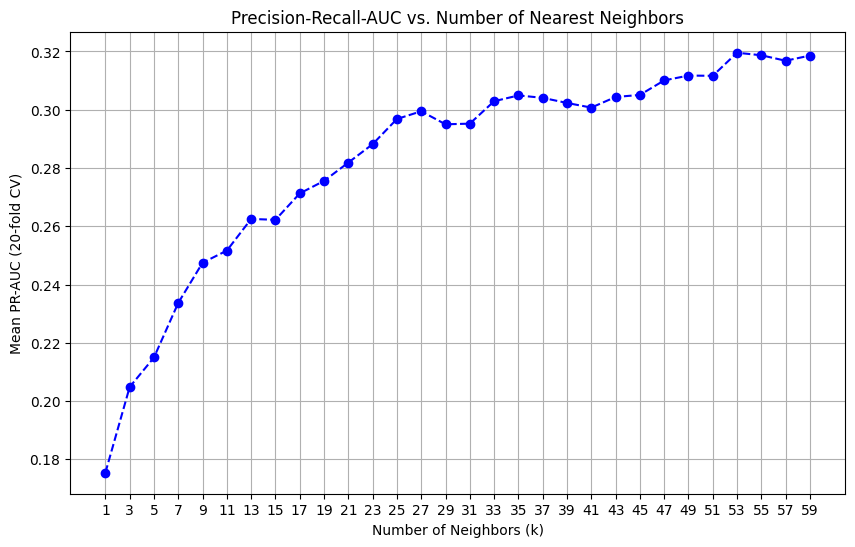

The optimal k value is: 53 with a PR-AUC of 0.3195


In [9]:

# 1. Define the range of k (n_neighbors)
# We use odd numbers to avoid ties in the voting process
k_values = [k for k in range(1, 60) if k % 2 != 0]
pr_auc_means = []
#train_scores = []

# 2. Perform Cross-Validation for each k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    # We use scoring='average_precision' for PR-AUC

    # Score on the training data itself
    #FROM ME: I'm not sure this is measuring what I want to measure
    knn.fit(X_scaled, y)
    #train_score = average_precision_score(Y, knn.predict_proba(X_scaled)[:, 1])
    #train_scores.append(train_score)
    
    
    # cv=10 is standard, but you can use cv=5 for faster computation
    #from me: cv is the number of folds

    #PR-AUC via cross-validation
    scores = cross_val_score(knn, X_scaled, y, cv=20, scoring='average_precision')
    pr_auc_means.append(scores.mean())

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_values, pr_auc_means, marker='o', linestyle='dashed', color='blue', label='Cross-Val')
#plt.plot(k_values, train_scores, linestyle='solid', color='red', label='Train')
#plt.legend()
plt.title('Precision-Recall-AUC vs. Number of Nearest Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean PR-AUC (20-fold CV)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# 4. Identify the "Best" k
optimal_k = k_values[np.argmax(pr_auc_means)]
print(f"The optimal k value is: {optimal_k} with a PR-AUC of {max(pr_auc_means):.4f}")